In [1]:
class Category:
    BOOKS = "Books"
    FASHION = "Clothing, Shoes or Jewelry"
    ELECTRONICS = "Electronics"
    HOME = "Home and Kitchen"
    CINEMA = "Movies and TV"
    VG = "Video Games"
    
class Sentiment:
    POSITIVE = "POSITIVE"
    NEGATIVE = "NEGATIVE"
    NEUTRAL = "NEUTRAL"

class Review:
    def __init__(self, category, text, score):
        self.category = category
        self.text = text
        self.score = score
        self.sentiment = self.getSentiment()
        
    def getSentiment(self):
        if self.score <= 2:
            return Sentiment.NEGATIVE
        elif self.score == 3:
            return Sentiment.NEUTRAL
        else:
            return Sentiment.POSITIVE

In [2]:
import random
random.seed(0) 

class ReviewCollection:
    def __init__(self, reviews):
        self.reviews = reviews
        
    def getText(self):
        return [x.text for x in self.reviews]
    
    def get_X(self, vectorizer):
        return vectorizer.transform(self.getText())
    
    def get_y(self):
        return [x.sentiment for x in self.reviews]
    
    def getCategory(self):
        return [x.category for x in self.reviews]
    
    def evenlyDistribute(self):
        negative = list(filter(lambda x: x.sentiment == Sentiment.NEGATIVE, self.reviews))
        positive = list(filter(lambda x: x.sentiment == Sentiment.POSITIVE, self.reviews))
        neutral = list(filter(lambda x: x.sentiment == Sentiment.NEUTRAL, self.reviews))

        minCount = min(len(negative), len(positive), len(neutral))
        
        negative = negative[:minCount]
        positive = positive[:minCount]
        neutral = neutral[:minCount]
        
        self.reviews = negative + positive + neutral
        
        random.shuffle(self.reviews)

In [3]:
import json
import numpy as np

datasets = ['Books',
            'Clothing_Shoes_Jewelry',
            'Electronics',
			'Home_Kitchen',
			'Movies_TV',
            'Video_Games']

Categories = [Category.BOOKS,
              Category.FASHION,
              Category.ELECTRONICS,
              Category.HOME,
              Category.CINEMA,
              Category.VG]

reviews = []
for i in range(len(datasets)):
    datasetPath = f'./LightData/Light_{datasets[i]}.json'
    category = Categories[i]
    
    with open(datasetPath) as f:
        for line in f:
            review = json.loads(line)
            reviews.append(Review(category, review['reviewText'], review['overall']))

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [5]:
train, test = train_test_split(reviews, train_size=2/3, random_state=42)

trainCollection = ReviewCollection(train)
trainCollection.evenlyDistribute()

testCollection = ReviewCollection(test)
testCollection.evenlyDistribute()

In [6]:
corpus = trainCollection.getText()

vectorizer = TfidfVectorizer()
vectorizer.fit(corpus)

TfidfVectorizer()

---
```python
	from sklearn.feature_extraction.text import CountVectorizer
	
	vectorizer = CountVectorizer(binary=True)
	vectorizer.fit(corpus)
```
---

In [7]:
train_X = trainCollection.get_X(vectorizer)
train_y = trainCollection.getCategory()

test_X = testCollection.get_X(vectorizer)
test_y = testCollection.getCategory()

---
```python
	train_X = vectorizer.transform(corpus)
	train_y = trainCollection.getCategory()

	test_X = vectorizer.transform(testCollection.getText())
	test_y = testCollection.getCategory()
```
---

In [8]:
from sklearn.svm import SVC

In [9]:
lsvc = SVC(C=10, kernel='linear', gamma='auto')
lsvc.fit(train_X, train_y)

SVC(C=10, gamma='auto', kernel='linear')

In [10]:
custom_test_X = ["The soundtrack perfectly complemented the scenes.",
				 "Battery life doesn't last as long as advertised.",
				 "Difficult to clean, food gets stuck in crevices.",
				 "Beautifully written, rich in detail.",
				 "Color faded after first wash, disappointed.",
                 "Graphics are outdated, needs an upgrade."]

custom_test = vectorizer.transform(custom_test_X)

predictions = lsvc.predict(custom_test)

print("Text Example", " "*41,"Prediction")
print("-"*84)
for i, j in zip(custom_test_X, predictions):
    print(f"{i: <50} ==> {j}")

Text Example                                           Prediction
------------------------------------------------------------------------------------
The soundtrack perfectly complemented the scenes.  ==> Movies and TV
Battery life doesn't last as long as advertised.   ==> Electronics
Difficult to clean, food gets stuck in crevices.   ==> Home and Kitchen
Beautifully written, rich in detail.               ==> Books
Color faded after first wash, disappointed.        ==> Clothing, Shoes or Jewelry
Graphics are outdated, needs an upgrade.           ==> Video Games


In [11]:
from sklearn.metrics import f1_score
import pandas as pd

In [12]:
y_pred = lsvc.predict(test_X)

labels = [Category.BOOKS, Category.FASHION,
		  Category.ELECTRONICS, Category.HOME,
		  Category.CINEMA, Category.VG]

f1_scores = f1_score(test_y, y_pred, average=None, labels=labels)

results = pd.DataFrame({'Category': labels, 'F1 Score': f1_scores})

results

,Category,F1 Score
0,Books,0.944794
1,"Clothing, Shoes or Jewelry",0.897444
2,Electronics,0.872559
3,Home and Kitchen,0.864155
4,Movies and TV,0.941730
5,Video Games,0.938129


In [13]:
lsvc.score(test_X, test_y)

0.9108728611652588

### GridSearch Tuning

In [14]:
from sklearn.model_selection import GridSearchCV

parameters = {'kernel':('linear', 'rbf'), 'C':[0.1, 1, 2, 4, 8, 12, 20]}
svc = SVC()
clf = GridSearchCV(svc, parameters, cv=5)
clf.fit(train_X, train_y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 2, 4, 8, 12, 20],
                         'kernel': ('linear', 'rbf')})

In [15]:
print("Best parameters found: ", clf.best_params_)

print("Best cross-validation score: {:.2f}".format(clf.best_score_))

Best parameters found:  {'C': 2, 'kernel': 'rbf'}
Best cross-validation score: 0.92


In [16]:
clf.score(test_X, test_y)

0.925059562486463

### Pickle Model

#### Saving The Classifier

In [17]:
import pickle

with open('./SavedModels/CategoryClassifier.pkl', 'wb') as f:
    pickle.dump(clf, f)
    
with open('./SavedModels/CategoryVectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

#### Loading The Classifier

In [18]:
import pickle 

with open('./SavedModels/CategoryClassifier.pkl', 'rb') as f:
    clf = pickle.load(f)

with open('./SavedModels/CategoryVectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

In [19]:
custom_test_X = ["Too many in-game purchases, feels like a cash grab.",
				 "Sharp blades, makes chopping effortless.",
				 "Camera quality is impressive, great for photos.",
				 "Comfortable fit, perfect for everyday wear."]

custom_test = vectorizer.transform(custom_test_X)

predictions = lsvc.predict(custom_test)

print("Text Example", " "*42,"Prediction")
print("-"*84)
for i, j in zip(custom_test_X, predictions):
    print(f"{i: <51} ==> {j}")

Text Example                                            Prediction
------------------------------------------------------------------------------------
Too many in-game purchases, feels like a cash grab. ==> Video Games
Sharp blades, makes chopping effortless.            ==> Home and Kitchen
Camera quality is impressive, great for photos.     ==> Electronics
Comfortable fit, perfect for everyday wear.         ==> Clothing, Shoes or Jewelry


### Confusion Matrix

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [21]:
y_pred = clf.predict(test_X)

labels = [Category.BOOKS, Category.FASHION,
		  Category.ELECTRONICS, Category.HOME,
		  Category.CINEMA, Category.VG]

cm = confusion_matrix(test_y, y_pred, labels=labels)

The function `confusion_matrix()` computes the confusion matrix by comparing the true labels `test_y` with the predicted labels `y_pred`.

In [22]:
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
df_cm

,Books,"Clothing, Shoes or Jewelry",Electronics,Home and Kitchen,Movies and TV,Video Games
Books,1359,2,12,12,33,2
"Clothing, Shoes or Jewelry",3,1384,24,61,4,4
Electronics,2,39,1361,78,7,20
Home and Kitchen,8,77,52,1302,1,2
Movies and TV,55,14,9,13,1622,7
Video Games,8,11,94,19,19,1514


We converted the confusion matrix `cm` into a pandas DataFrame, labeling its rows and columns using the `labels` list for easier plotting.

<Axes: >

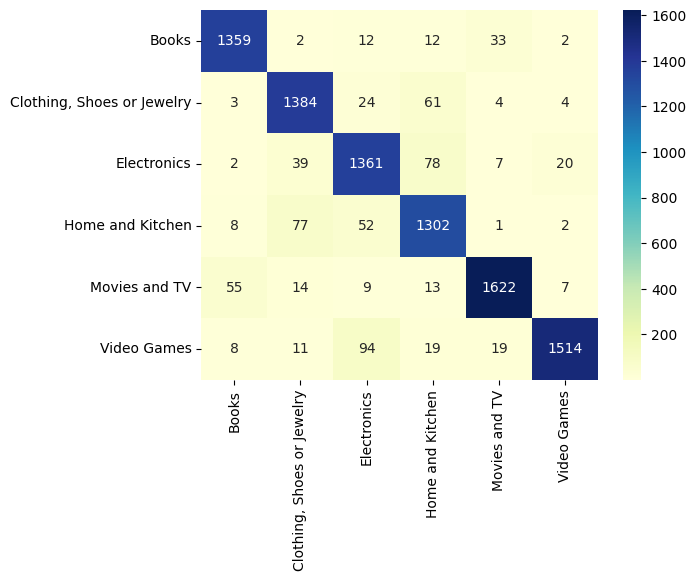

In [23]:
sns.heatmap(df_cm, annot=True, fmt='d', cmap="YlGnBu")

It's not surprising to have **59** or **61** confusions between the categories "**Home and Kitchen**" and "**Electronics**", given the extensive use of electronic devices in the kitchen.